# Practical 4: Customer Feedback Analysis using NLP with NLTK

This notebook performs complete text preprocessing and linguistic analysis for customer feedback reviews.

## 1) Install/Import Dependencies
If NLTK is not installed, uncomment and run the pip line below.

In [10]:
# !pip install nltk

import re
from pathlib import Path
from collections import Counter

import nltk
from nltk import FreqDist, ne_chunk, pos_tag, sent_tokenize, word_tokenize
from nltk.corpus import opinion_lexicon, stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

## 2) Download Required NLTK Resources

In [11]:
resources = [
    "punkt",
    "punkt_tab",
    "stopwords",
    "wordnet",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "maxent_ne_chunker",
    "maxent_ne_chunker_tab",
    "words",
    "opinion_lexicon",
    "omw-1.4",
]

for resource in resources:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

print("NLTK resources checked/downloaded.")

NLTK resources checked/downloaded.


## 3) Load Feedback Text File
Make sure `customer_feedback.txt` is in the same project folder.

In [12]:
feedback_file = Path.cwd() / "customer_feedback.txt"
if not feedback_file.exists():
    raise FileNotFoundError(f"File not found: {feedback_file}")

text = feedback_file.read_text(encoding="utf-8").strip()
print(f"Loaded feedback characters: {len(text)}")

Loaded feedback characters: 1527


## 4) NLP Processing Functions

In [13]:
def clean_and_tokenize_text(text: str):
    sentences = sent_tokenize(text)
    all_tokens = word_tokenize(text)

    lowercase_tokens = [token.lower() for token in all_tokens]

    cleaned_tokens = [re.sub(r"[^a-zA-Z]", "", token) for token in lowercase_tokens]
    cleaned_tokens = [token for token in cleaned_tokens if token]

    stop_words = set(stopwords.words("english"))
    filtered_tokens = [token for token in cleaned_tokens if token not in stop_words]

    return sentences, all_tokens, filtered_tokens


def perform_stemming(tokens):
    stemmer = PorterStemmer()
    return [stemmer.stem(token) for token in tokens]


def perform_lemmatization(tokens):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in tokens]


def get_pos_tags(tokens):
    return pos_tag(tokens)


def get_named_entities(pos_tagged_tokens):
    return ne_chunk(pos_tagged_tokens)


def get_top_frequent_words(tokens, top_n=10):
    frequency_distribution = FreqDist(tokens)
    return frequency_distribution.most_common(top_n), frequency_distribution


def count_sentiment_words(tokens):
    positive_words = set(opinion_lexicon.positive())
    negative_words = set(opinion_lexicon.negative())

    token_counter = Counter(tokens)

    positive_count = sum(count for word, count in token_counter.items() if word in positive_words)
    negative_count = sum(count for word, count in token_counter.items() if word in negative_words)

    return positive_count, negative_count

## 5) Run Complete Analysis

In [14]:
sentences, raw_tokens, filtered_tokens = clean_and_tokenize_text(text)
stemmed_tokens = perform_stemming(filtered_tokens)
lemmatized_tokens = perform_lemmatization(filtered_tokens)
pos_tags = get_pos_tags(lemmatized_tokens)
named_entities = get_named_entities(pos_tags)
top_words, frequency_distribution = get_top_frequent_words(lemmatized_tokens, top_n=10)
positive_count, negative_count = count_sentiment_words(lemmatized_tokens)

print('=' * 70)
print('1) SENTENCE TOKENIZATION')
print('=' * 70)
print(f'Total sentences: {len(sentences)}')
for index, sentence in enumerate(sentences, start=1):
    print(f'{index:02d}. {sentence}')

print('\n' + '=' * 70)
print('2) WORD TOKENIZATION')
print('=' * 70)
print(f'Total raw tokens: {len(raw_tokens)}')
print('First 40 raw tokens:')
print(raw_tokens[:40])

print('\n' + '=' * 70)
print('3) LOWERCASE + PUNCTUATION REMOVAL + STOPWORD REMOVAL')
print('=' * 70)
print(f'Total cleaned tokens (after stopword removal): {len(filtered_tokens)}')
print('First 40 cleaned tokens:')
print(filtered_tokens[:40])

print('\n' + '=' * 70)
print('4) STEMMING (PorterStemmer)')
print('=' * 70)
print('First 40 stemmed tokens:')
print(stemmed_tokens[:40])

print('\n' + '=' * 70)
print('5) LEMMATIZATION (WordNetLemmatizer)')
print('=' * 70)
print('First 40 lemmatized tokens:')
print(lemmatized_tokens[:40])

print('\n' + '=' * 70)
print('6) PART-OF-SPEECH TAGGING')
print('=' * 70)
print('First 40 POS tags:')
print(pos_tags[:40])

print('\n' + '=' * 70)
print('7) NAMED ENTITY RECOGNITION')
print('=' * 70)
print('Named entity parse tree (first pass):')
print(named_entities)

print('\n' + '=' * 70)
print('8) FREQUENCY DISTRIBUTION')
print('=' * 70)
print('Top 10 frequent words:')
for word, freq in top_words:
    print(f'{word}: {freq}')

print('\n' + '=' * 70)
print('9) POSITIVE & NEGATIVE WORD COUNT')
print('=' * 70)
print(f'Positive word count: {positive_count}')
print(f'Negative word count: {negative_count}')

if positive_count > negative_count:
    print('Overall lexical sentiment: Mostly Positive')
elif negative_count > positive_count:
    print('Overall lexical sentiment: Mostly Negative')
else:
    print('Overall lexical sentiment: Neutral / Balanced')

print('\n' + '=' * 70)
print('10) FULL FREQUENCY DISTRIBUTION SIZE')
print('=' * 70)
print(f'Unique vocabulary size after preprocessing: {len(frequency_distribution)}')

1) SENTENCE TOKENIZATION
Total sentences: 30
01. The product quality is excellent and delivery was fast.
02. Customer support was poor and the app is slow.
03. I love the user interface but the price is high.
04. The packaging was damaged when it arrived in Mumbai.
05. Amazon replacement process was smooth and quick.
06. Flipkart sent the wrong color of the headphones.
07. The battery life of this Samsung phone is amazing.
08. The camera performance is terrible in low light.
09. I received my order from Delhi two days early.
10. The courier service lost my package once again.
11. Apple Watch integration works perfectly with the app.
12. The checkout experience on the website is confusing.
13. I am happy with the build quality of this laptop.
14. The keyboard keys feel cheap and noisy.
15. Customer care from Myntra solved my issue politely.
16. The return policy is unfair and very strict.
17. The screen display is bright, sharp, and beautiful.
18. The charging adapter stopped working in

## 6) Visualization Setup
We add plotting and metrics libraries for charts and performance evaluation.

In [15]:
# If needed, uncomment the next line
#!pip install matplotlib seaborn pandas scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support, classification_report

sns.set_style("whitegrid")
print("Visualization and metrics libraries loaded.")

Visualization and metrics libraries loaded.


## 7) Visualizations
Top frequent terms and overall positive vs negative lexical counts.

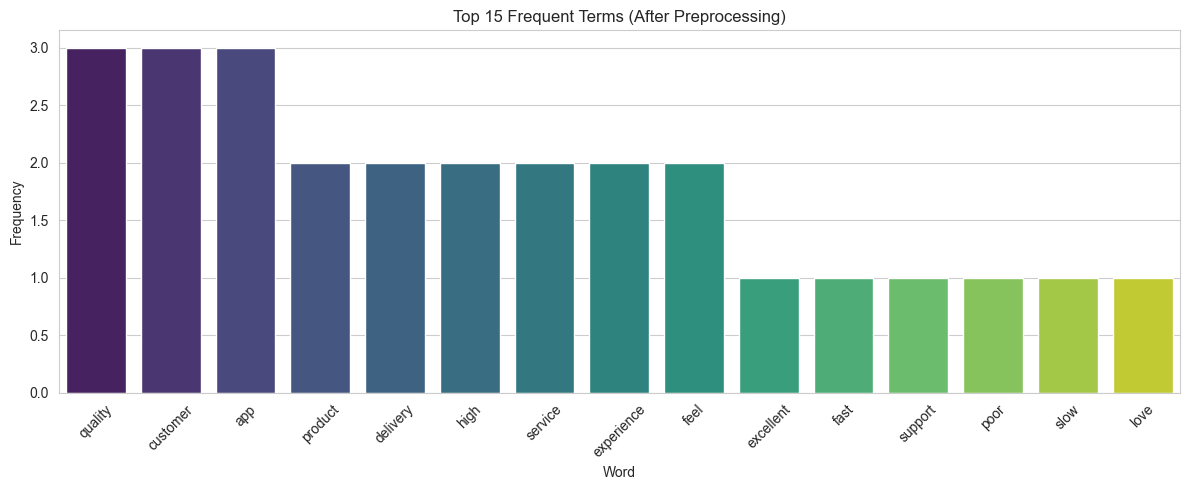

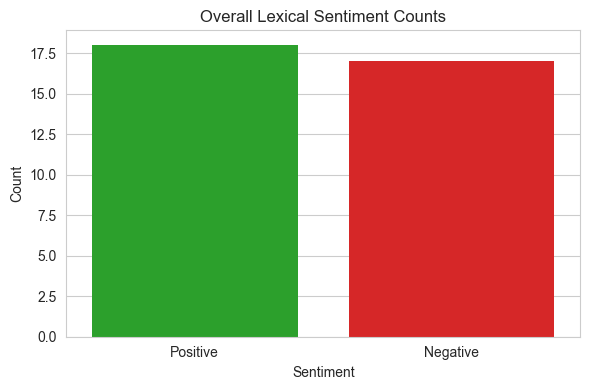

,Sentiment,Count
0,Positive,18
1,Negative,17


In [16]:
# --- Chart 1: Top frequent words ---
top_15 = frequency_distribution.most_common(15)
freq_df = pd.DataFrame(top_15, columns=["word", "count"])

plt.figure(figsize=(12, 5))
sns.barplot(data=freq_df, x="word", y="count", hue="word", palette="viridis", legend=False)
plt.title("Top 15 Frequent Terms (After Preprocessing)")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Chart 2: Overall positive vs negative word counts ---
sentiment_counts_df = pd.DataFrame(
    {
        "Sentiment": ["Positive", "Negative"],
        "Count": [positive_count, negative_count],
    }
)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=sentiment_counts_df,
    x="Sentiment",
    y="Count",
    hue="Sentiment",
    palette={"Positive": "#2ca02c", "Negative": "#d62728"},
    legend=False,
    dodge=False,
    saturation=1,
    edgecolor="none",
)
plt.title("Overall Lexical Sentiment Counts")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

sentiment_counts_df

## 8) Performance Metrics (Sentiment Classification)
This evaluates lexicon-based sentence sentiment predictions against manually annotated expected labels.

Accuracy:  0.800
Precision: 0.592
Recall:    0.571
F1-score:  0.581


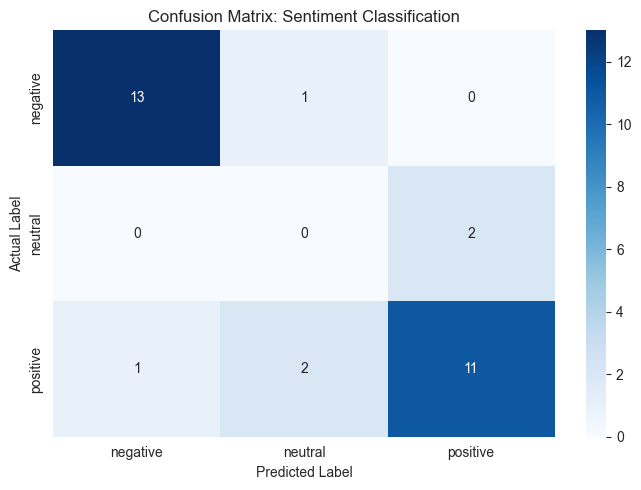

,precision,recall,f1-score,support
negative,0.929,0.929,0.929,14.0
neutral,0.000,0.000,0.000,2.0
positive,0.846,0.786,0.815,14.0
accuracy,0.800,0.800,0.800,0.8
macro avg,0.592,0.571,0.581,30.0
weighted avg,0.828,0.800,0.814,30.0


,Sentence,Actual,Predicted
0,The product quality is excellent and delivery ...,positive,positive
1,Customer support was poor and the app is slow.,negative,negative
2,I love the user interface but the price is high.,neutral,positive
3,The packaging was damaged when it arrived in M...,negative,negative
4,Amazon replacement process was smooth and quick.,positive,positive
5,Flipkart sent the wrong color of the headphones.,negative,negative
6,The battery life of this Samsung phone is amaz...,positive,positive
7,The camera performance is terrible in low light.,negative,negative
8,I received my order from Delhi two days early.,positive,neutral
9,The courier service lost my package once again.,negative,negative


In [17]:
label_order = ["negative", "neutral", "positive"]

positive_lex = set(opinion_lexicon.positive())
negative_lex = set(opinion_lexicon.negative())
stop_words = set(stopwords.words("english"))

def sentence_sentiment_label(sentence: str) -> str:
    tokens = word_tokenize(sentence.lower())
    tokens = [re.sub(r"[^a-zA-Z]", "", token) for token in tokens]
    tokens = [token for token in tokens if token and token not in stop_words]

    pos_score = sum(1 for token in tokens if token in positive_lex)
    neg_score = sum(1 for token in tokens if token in negative_lex)

    if pos_score > neg_score:
        return "positive"
    if neg_score > pos_score:
        return "negative"
    return "neutral"

predicted_labels = [sentence_sentiment_label(sentence) for sentence in sentences]

# Manual expected labels for the 30 feedback sentences in customer_feedback.txt
actual_labels = [
    "positive", "negative", "neutral", "negative", "positive",
    "negative", "positive", "negative", "positive", "negative",
    "positive", "negative", "positive", "negative", "positive",
    "negative", "positive", "negative", "positive", "negative",
    "positive", "negative", "negative", "positive", "negative",
    "positive", "positive", "negative", "positive", "neutral",
]

if len(actual_labels) != len(predicted_labels):
    raise ValueError("Actual and predicted label counts do not match.")

metrics_df = pd.DataFrame(
    {
        "Sentence": sentences,
        "Actual": actual_labels,
        "Predicted": predicted_labels,
    }
)

cm = confusion_matrix(actual_labels, predicted_labels, labels=label_order)
accuracy = accuracy_score(actual_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    actual_labels, predicted_labels, average="macro", zero_division=0
)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_order, yticklabels=label_order
)
plt.title("Confusion Matrix: Sentiment Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

report = classification_report(
    actual_labels, predicted_labels, labels=label_order, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).T
display(report_df.round(3))

metrics_df.head(10)